# 03 Artists EDA

This notebook explores the artist-level data.

We focus on:
- artist popularity
- follower counts
- genre information
- most frequent artists
- connections between artists and tracks

## 1. Load Artists Data

In [1]:
from pathlib import Path
import sys
import warnings

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from config.paths import DUCKDB_PATH

con = duckdb.connect(DUCKDB_PATH)

In [2]:
artists = con.execute("SELECT * FROM artists").df()

artists.shape

(56129, 9)

In [3]:
artists.head()

,column0,artist_popularity,followers,genres,id,name,track_id,track_name_prev,type
0,0,44,23230,"['sertanejo', 'sertanejo pop', 'sertanejo trad...",4mGnpjhqgx4RUdsIJiURdo,Juliano Cezar,0wmDmAILuW9e2aRttkl4aC,track_9,artist
1,1,22,313,[],1dLnVku4VQUOLswwDFvRc9,The Grenadines,4wqwj0gA8qPZKLl5WVqXml,track_30,artist
2,2,26,1596,['danish pop rock'],6YVY310fjfUzKi8hiqR7iK,Gangway,1bFqWDbvHmZe2f4Nf9qaD8,track_38,artist
3,3,31,149,['uk alternative pop'],2VElyouiCfoYPDJluzwJwK,FADES,3MFSUBAidPzRBbIS7BDj1S,track_34,artist
4,4,21,11,['french baroque'],4agVy03qW8juSysCTUOuDI,Jean-Pierre Guignon,2r3q57FhxdsCyYr0kuDq4b,track_26,artist


## 2. Basic Dataset Information

In [4]:
artists.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56129 entries, 0 to 56128
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   column0            56129 non-null  int64 
 1   artist_popularity  56129 non-null  int64 
 2   followers          56129 non-null  int64 
 3   genres             56129 non-null  object
 4   id                 56129 non-null  object
 5   name               56129 non-null  object
 6   track_id           56129 non-null  object
 7   track_name_prev    56129 non-null  object
 8   type               56129 non-null  object
dtypes: int64(3), object(6)
memory usage: 3.9+ MB


In [5]:
artists.describe(include="all")

,column0,artist_popularity,followers,genres,id,name,track_id,track_name_prev,type
count,56129.000000,56129.000000,5.612900e+04,56129,56129,56129,56129,56129,56129
unique,NaN,NaN,NaN,13314,56129,55506,44895,339,1
top,NaN,NaN,NaN,[],4mGnpjhqgx4RUdsIJiURdo,Sasha,3rPsrmdQkua16ZeXfYP4D6,track_12,artist
freq,NaN,NaN,NaN,23540,1,5,21,1098,56129
mean,28064.000000,34.387447,7.796041e+04,NaN,NaN,NaN,NaN,NaN,NaN
std,16203.190967,16.917287,5.942273e+05,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,0.000000,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN
25%,14032.000000,22.000000,1.820000e+02,NaN,NaN,NaN,NaN,NaN,NaN
50%,28064.000000,34.000000,1.734000e+03,NaN,NaN,NaN,NaN,NaN,NaN
75%,42096.000000,46.000000,1.520300e+04,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
artists.isna().sum().sort_values(ascending=False)

column0              0
artist_popularity    0
followers            0
genres               0
id                   0
name                 0
track_id             0
track_name_prev      0
type                 0
dtype: int64

In [7]:
artists.duplicated().sum()

0

## 3. Artist Popularity Distribution

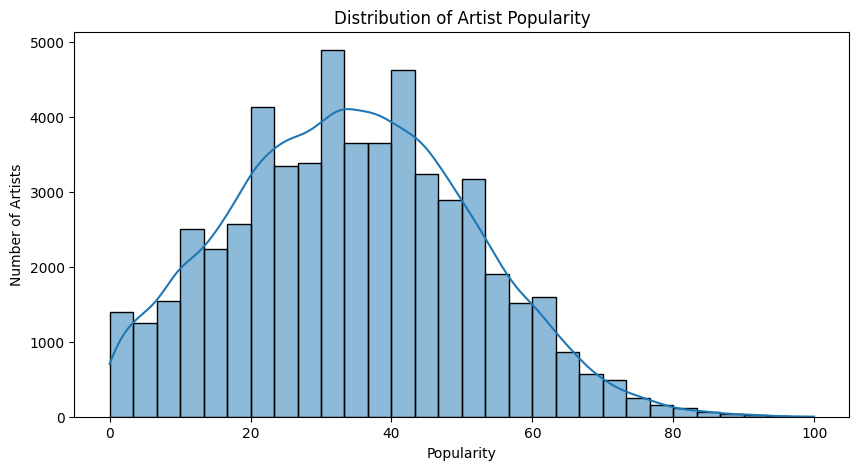

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(artists["artist_popularity"], bins=30, kde=True)
plt.title("Distribution of Artist Popularity")
plt.xlabel("Popularity")
plt.ylabel("Number of Artists")
plt.show()

In [9]:
artists["artist_popularity"].describe()

count    56129.000000
mean        34.387447
std         16.917287
min          0.000000
25%         22.000000
50%         34.000000
75%         46.000000
max        100.000000
Name: artist_popularity, dtype: float64

## 4. Followers Analysis

In [10]:
artists["followers"].describe()

count    5.612900e+04
mean     7.796041e+04
std      5.942273e+05
min      0.000000e+00
25%      1.820000e+02
50%      1.734000e+03
75%      1.520300e+04
max      4.156169e+07
Name: followers, dtype: float64

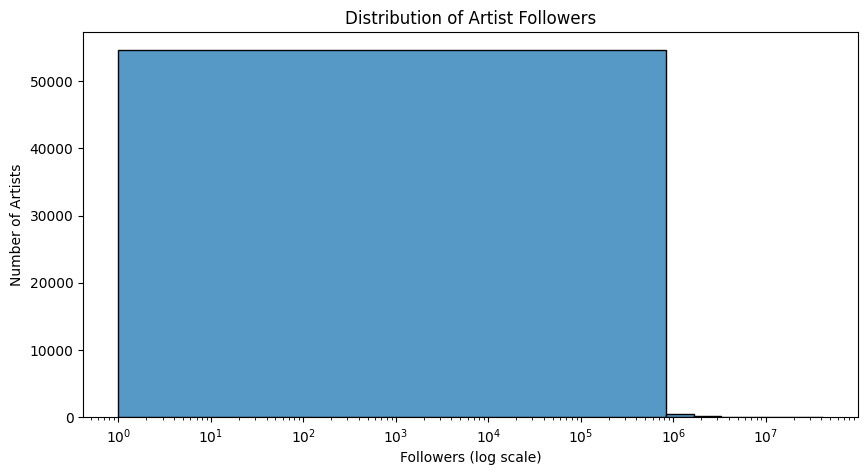

In [11]:
plt.figure(figsize=(10, 5))
sns.histplot(artists[artists["followers"] > 0]["followers"], bins=50)
plt.xscale("log")
plt.title("Distribution of Artist Followers")
plt.xlabel("Followers (log scale)")
plt.ylabel("Number of Artists")
plt.show()

## 5. Popularity and Followers

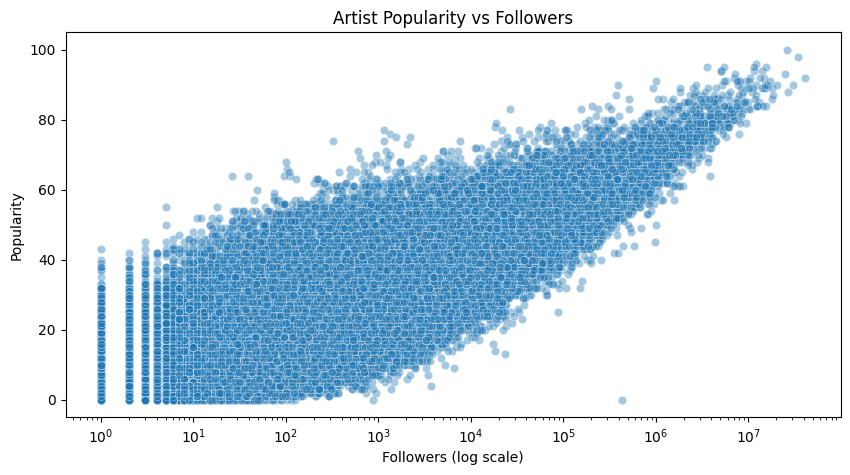

In [12]:
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=artists[artists["followers"] > 0],
    x="followers",
    y="artist_popularity",
    alpha=0.4
)
plt.xscale("log")
plt.title("Artist Popularity vs Followers")
plt.xlabel("Followers (log scale)")
plt.ylabel("Popularity")
plt.show()

In [13]:
artists[["followers", "artist_popularity"]].corr()

,followers,artist_popularity
followers,1.000000,0.288724
artist_popularity,0.288724,1.000000


## 6. Most Popular Artists

In [14]:
top_popular_artists = artists.sort_values(
    by=["artist_popularity", "followers"], 
    ascending=False
).head(20)

top_popular_artists[["name", "artist_popularity", "followers", "genres"]]

,name,artist_popularity,followers,genres
42872,Ariana Grande,100,26309771,"['dance pop', 'pop', 'post-teen pop']"
53392,Drake,98,34680740,"['canadian hip hop', 'canadian pop', 'hip hop'..."
49775,Post Malone,96,12150628,"['pop', 'rap']"
52306,Ozuna,95,15389549,"['reggaeton', 'trap latino']"
55822,XXXTENTACION,95,11564320,"['emo rap', 'miami hip hop']"
53406,Khalid,95,5476601,['pop']
49695,Juice WRLD,95,3607186,['chicago rap']
39126,Queen,94,14130233,"['glam rock', 'rock']"
55502,Bad Bunny,94,11616538,"['reggaeton', 'trap latino']"
52280,Anuel Aa,94,5103877,"['reggaeton flow', 'trap latino']"


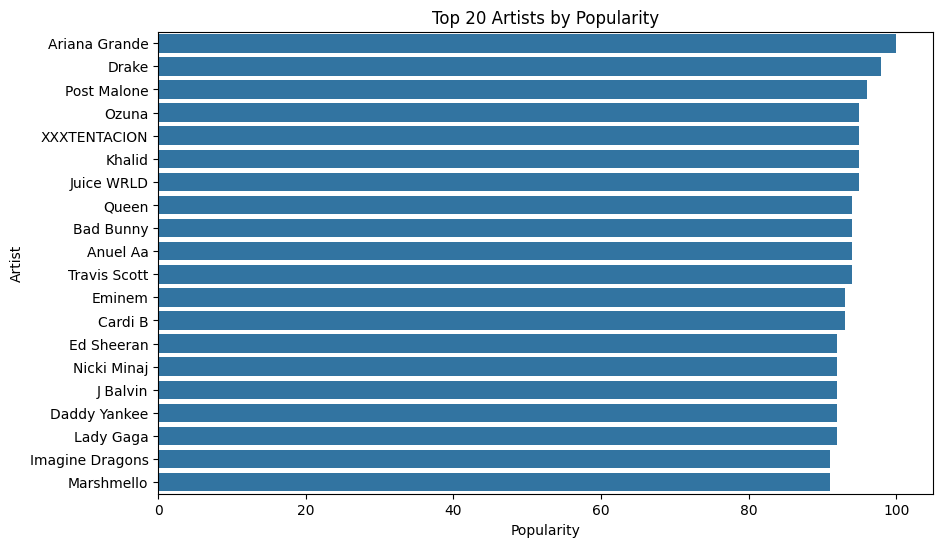

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_popular_artists,
    x="artist_popularity",
    y="name"
)
plt.title("Top 20 Artists by Popularity")
plt.xlabel("Popularity")
plt.ylabel("Artist")
plt.show()

## 7. Most Followed Artists

In [16]:
top_followed_artists = artists.sort_values(
    by="followers", 
    ascending=False
).head(20)

top_followed_artists[["name", "followers", "artist_popularity", "genres"]]

,name,followers,artist_popularity,genres
55251,Ed Sheeran,41561693,92,"['pop', 'uk pop']"
53392,Drake,34680740,98,"['canadian hip hop', 'canadian pop', 'hip hop'..."
52620,Rihanna,30560149,90,"['dance pop', 'pop', 'post-teen pop', 'r&b', '..."
54447,Justin Bieber,26824224,88,"['canadian pop', 'dance pop', 'pop', 'post-tee..."
42872,Ariana Grande,26309771,100,"['dance pop', 'pop', 'post-teen pop']"
45173,Eminem,25180454,93,"['detroit hip hop', 'g funk', 'hip hop', 'rap']"
56012,Bruno Mars,20226989,90,"['dance pop', 'pop', 'post-teen pop']"
54980,Coldplay,18490021,87,"['permanent wave', 'pop']"
55997,David Guetta,18008912,89,"['dance pop', 'edm', 'pop']"
52563,Beyoncé,17864458,86,"['dance pop', 'pop', 'post-teen pop', 'r&b']"


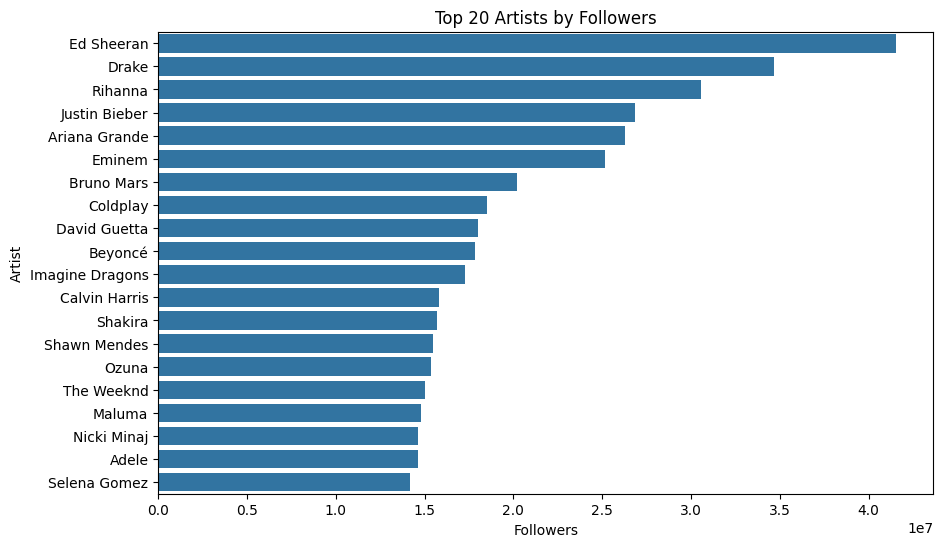

In [17]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_followed_artists,
    x="followers",
    y="name"
)
plt.title("Top 20 Artists by Followers")
plt.xlabel("Followers")
plt.ylabel("Artist")
plt.show()

## 8. Genre Information

In [18]:
artists["genres"].head(20)

0     ['sertanejo', 'sertanejo pop', 'sertanejo trad...
1                                                    []
2                                   ['danish pop rock']
3                                ['uk alternative pop']
4                                    ['french baroque']
5                                                    []
6                                                    []
7                                                    []
8                                                    []
9                               ['classic finnish pop']
10                                                   []
11    ['pagode', 'sertanejo', 'sertanejo pop', 'sert...
12                                                   []
13                                                   []
14                                                   []
15                                                   []
16                                                   []
17                                 ['abstract hi

In [19]:
artists["has_genres"] = artists["genres"].apply(
    lambda x: 0 if pd.isna(x) or x == "[]" else 1
)

artists["has_genres"].value_counts()

has_genres
1    32589
0    23540
Name: count, dtype: int64

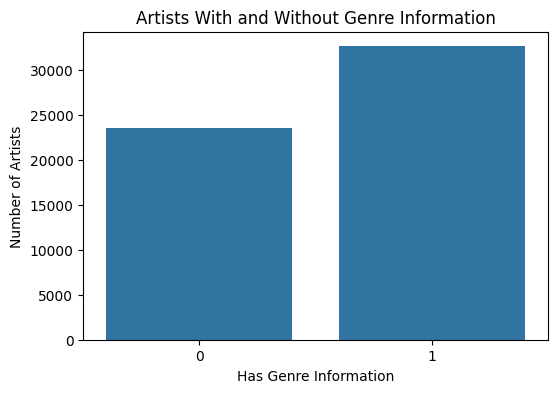

In [20]:
plt.figure(figsize=(6, 4))
sns.countplot(data=artists, x="has_genres")
plt.title("Artists With and Without Genre Information")
plt.xlabel("Has Genre Information")
plt.ylabel("Number of Artists")
plt.show()

## 9. Artist Popularity Categories

In [27]:
artists["popularity_group"] = pd.cut(
    artists["artist_popularity"],
    bins=[0, 20, 40, 60, 80, 100],
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

artists["popularity_group"].value_counts().sort_index()

popularity_group
Very Low     12118
Low          23298
Medium       16586
High          3526
Very High      208
Name: count, dtype: int64

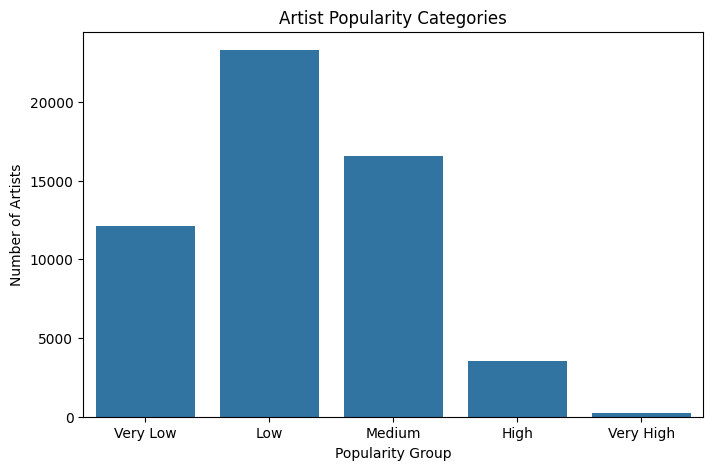

In [28]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=artists,
    x="popularity_group",
    order=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

plt.title("Artist Popularity Categories")
plt.xlabel("Popularity Group")
plt.ylabel("Number of Artists")

plt.show()

## 10. Relationship Between Followers and Popularity

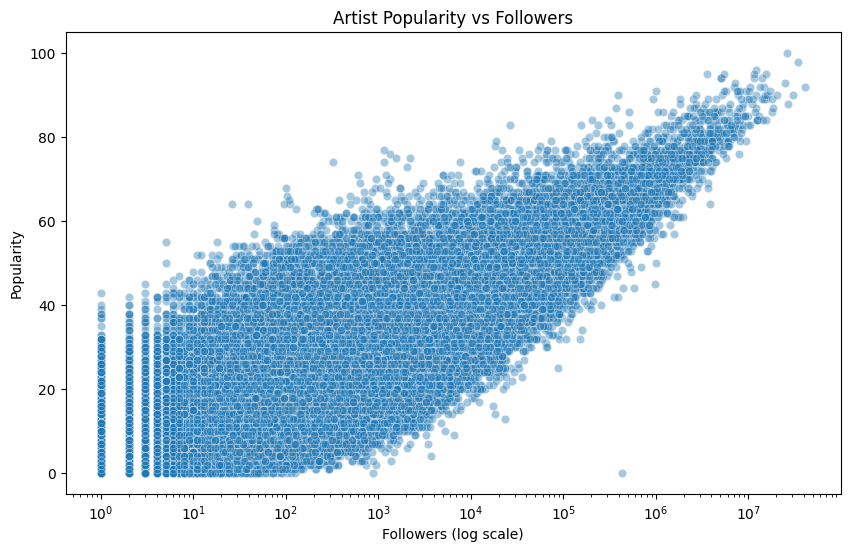

In [30]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=artists[artists["followers"] > 0],
    x="followers",
    y="artist_popularity",
    alpha=0.4
)

plt.xscale("log")

plt.title("Artist Popularity vs Followers")
plt.xlabel("Followers (log scale)")
plt.ylabel("Popularity")

plt.show()

## 11. Most Popular Artists

In [33]:
top_artists = artists.sort_values(
    by=["artist_popularity", "followers"],
    ascending=False
).head(15)

top_artists[
    ["name", "artist_popularity", "followers", "genres"]
]

,name,artist_popularity,followers,genres
42872,Ariana Grande,100,26309771,"['dance pop', 'pop', 'post-teen pop']"
53392,Drake,98,34680740,"['canadian hip hop', 'canadian pop', 'hip hop'..."
49775,Post Malone,96,12150628,"['pop', 'rap']"
52306,Ozuna,95,15389549,"['reggaeton', 'trap latino']"
55822,XXXTENTACION,95,11564320,"['emo rap', 'miami hip hop']"
53406,Khalid,95,5476601,['pop']
49695,Juice WRLD,95,3607186,['chicago rap']
39126,Queen,94,14130233,"['glam rock', 'rock']"
55502,Bad Bunny,94,11616538,"['reggaeton', 'trap latino']"
52280,Anuel Aa,94,5103877,"['reggaeton flow', 'trap latino']"


## 12. Artist-Level Notes for Recommendation System

Artist information can provide an additional layer for the recommendation system beyond just audio features. Songs from the same artist are often more likely to match a listener’s preferences, especially when users already enjoy a certain style or sound.

Popularity and follower counts can also help distinguish between more mainstream artists and smaller or niche artists. This may become useful later when balancing recommendations between highly popular songs and less known tracks.

Genre information is another important aspect, since artists with similar genres or musical styles may produce tracks that fit well together in recommendation results. Combining artist data with audio features could therefore improve the overall relevance and diversity of recommendations.

## 13. Initial Notes

The artist dataset shows strong imbalance. A small number of artists have very high popularity and follower counts, while many artists have much lower visibility.

This is important for the recommendation system because recommending only highly popular artists could make the system less diverse. Therefore, artist information should be used together with track features, audio features, and genre information rather than as the only recommendation criterion.

In [34]:
con.close()